In [1]:
## 2026.05.18 using FineST env
##            load Xenium annotation data
##            - the annotation form transcriptomic - 
##            - Select4: VUHD113, VUILD107MA, VUILD102LA, VUILD96LA
##            - HE cells: built from Weiqin cells_partitioned_by_annotation.csv (see SELECT4_SAMPLES)
##            - Lu help run Star_Dist - data/Xemiun/lung/StarDist_Segment/
## 2026.05.19 VUHD113- VUILD107MA- VUILD102LA- VUILD96LA
## 2026.06.19 All datset for Complete_Cases: 25; Incomplete_Cases: 20
## 2026.06.22 Adjust the um-pixel for Incomplete_Cases, Adjust the HE_lowres.jpg y, and plot spatialmapping

In [2]:
# cd /home/lingyu/ssd2/Python/Collaborate/esccAI
# bash code/Xenium_lung/demo_VUILD107MA.sh
# bash code/Xenium_lung/demo_VUILD102LA.sh
# bash code/Xenium_lung/demo_VUILD96LA.sh

In [1]:
## for AI edit
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
import os
os.chdir(f'{path}Collaborate/esccAI/data/')
!pwd

## Load function
import sys
from pathlib import Path
_xenium_dir = Path("/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Xenium_lung")
if str(_xenium_dir) not in sys.path:
    sys.path.insert(0, str(_xenium_dir))

from plot_HEanno_spatial_labels import plot_spatial_he_maps, DEFAULT_FIGURES_DIR, DEFAULT_SPATIAL_COLS
from extract_cell_spatial_coords import extract_labels, labels_csv_path
from match_HEanno_with_sample_pix import write_per_sample_cells, COMPLETE_CASES, INCOMPLETE_CASES
from xenium_coords import add_he_pixel_columns
from copy_stardist_to_cases import (
    STARDIST_SOURCE,
    STARDIST_CSV_SUFFIX,
    copy_stardist_csvs,
    resolve_case_dir,
    stardist_source_csv,
)

## load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger("ome_zarr").setLevel(logging.ERROR)


Xenium_lung_dir = f'{path}Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/'


/ssd2/users/lingyu/Python/Collaborate/esccAI/data


## 1. Load annotation for niche and tissue
Load data from Weiqin
- /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Annotation/HE_Annotations
- cells_partitioned_by_annotation.csv   with 133.9M
- 'annotation_type' is same with 'Annotation_Type'

In [4]:
# Per-cell table: subset from Weiqin (same columns as cells_partitioned_by_annotation.csv)

Xenium_lung_dir = f'{path}Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/'
HE_anno_GT_dir = f'{Xenium_lung_dir}Annotation/HE_Annotations/cells_partitioned_by_annotation.csv'

HE_anno_GT_df = pd.read_csv(HE_anno_GT_dir)
print('The shape of HE_Annotations:', HE_anno_GT_df.shape)
print('Total samples:', len(HE_anno_GT_df['sample'].unique()))
display(HE_anno_GT_df)

The shape of HE_Annotations: (790934, 16)
Total samples: 45


,sample,full_cell_id,cell_id,annotation_type_instance,annotation_type,annotation_instance,Annotation_Type,num_cells_annotation_type_instance,x_centroid,y_centroid,CNiche,TNiche,final_CT,final_lineage,final_sublineage,tma
0,VUHD116A,VUHD116A_aaaaaacg-1,aaaaaacg-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1663.692175,82.937963,C8,T4,SMCs/Pericytes,Mesenchymal,Mesenchymal,TMA1
1,VUHD116A,VUHD116A_aaaaaacl-1,aaaaaacl-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1669.976282,382.249965,C8,T4,Capillary,Endothelial,Endothelial,TMA1
2,VUHD116A,VUHD116A_aaaaaacp-1,aaaaaacp-1,normal_alveoli_3,normal_alveoli,2,Normal Alveoli,1512,2496.735547,757.727945,C8,T4,Alveolar FBs,Mesenchymal,Mesenchymal,TMA1
3,VUHD116A,VUHD116A_aaaaaadb-1,aaaaaadb-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1644.208582,73.882906,C8,T4,Capillary,Endothelial,Endothelial,TMA1
4,VUHD116A,VUHD116A_aaaaaadc-1,aaaaaadc-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1658.244061,379.432784,C8,T4,Capillary,Endothelial,Endothelial,TMA1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790929,VUILD58,VUILD58_ofeondlc-1,ofeondlc-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2280.139160,3853.644531,C4,T6,Myofibroblasts,Mesenchymal,Mesenchymal,TMA5
790930,VUILD58,VUILD58_ofeooakp-1,ofeooakp-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2279.693359,3816.789795,C4,T9,Alveolar FBs,Mesenchymal,Mesenchymal,TMA5
790931,VUILD58,VUILD58_ofeoonjb-1,ofeoonjb-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2317.959961,3853.163086,C4,T9,Alveolar FBs,Mesenchymal,Mesenchymal,TMA5
790932,VUILD58,VUILD58_offoldom-1,offoldom-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2375.071533,3974.686768,C4,T6,Alveolar FBs,Mesenchymal,Mesenchymal,TMA5


In [5]:
# Cell counts in HE_anno_GT_df by Complete_Cases vs Incomplete_Cases
# HE_anno_GT_df uses Weiqin sample IDs; case folders use paper IDs (see sample_mapping.py).
from match_HEanno_with_sample_pix import list_case_sample_dirs
from sample_mapping import WEIQIN_TO_PAPER

complete_paper_samples = set(list_case_sample_dirs(COMPLETE_CASES).keys())
incomplete_paper_samples = set(list_case_sample_dirs(INCOMPLETE_CASES).keys())


def _cases_set(weiqin_sample_id: str) -> str:
    paper_id = WEIQIN_TO_PAPER.get(weiqin_sample_id, weiqin_sample_id)
    if paper_id in complete_paper_samples:
        return "Complete_Cases"
    if paper_id in incomplete_paper_samples:
        return "Incomplete_Cases"
    return "other"


HE_anno_GT_df = HE_anno_GT_df.copy()
HE_anno_GT_df["paper_sample"] = HE_anno_GT_df["sample"].map(
    lambda s: WEIQIN_TO_PAPER.get(s, s)
)
HE_anno_GT_df["cases_set"] = HE_anno_GT_df["sample"].map(_cases_set)

cells_by_set = (
    HE_anno_GT_df.groupby("cases_set", sort=False)
    .agg(n_cells=("sample", "size"), n_samples=("sample", "nunique"))
    .reindex(["Complete_Cases", "Incomplete_Cases", "other"])
)
print("=== Cells in HE_anno_GT_df by case folder ===")
print(cells_by_set.to_string())
print(f"\nGrand total: {len(HE_anno_GT_df):,} cells across {HE_anno_GT_df['sample'].nunique()} Weiqin samples")

per_sample = (
    HE_anno_GT_df.groupby(["cases_set", "paper_sample", "sample"], sort=False)
    .size()
    .reset_index(name="n_cells")
    .sort_values(["cases_set", "n_cells"], ascending=[True, False])
)
display(per_sample)

other_samples = sorted(
    HE_anno_GT_df.loc[HE_anno_GT_df["cases_set"] == "other", "sample"].unique()
)
if other_samples:
    print("Weiqin samples without Complete/Incomplete folder:", other_samples)


=== Cells in HE_anno_GT_df by case folder ===
                   n_cells  n_samples
cases_set                            
Complete_Cases    637738.0       25.0
Incomplete_Cases  153196.0       20.0
other                  NaN        NaN

Grand total: 790,934 cells across 45 Weiqin samples


,cases_set,paper_sample,sample,n_cells
18,Complete_Cases,VUILD110LA,VUILD110,97221
17,Complete_Cases,VUILD106MA,VUILD106,91778
19,Complete_Cases,VUILD115MA,VUILD115,58850
16,Complete_Cases,THD0008,THD0008,36781
6,Complete_Cases,VUILD96MA,VUILD96MF,36615
5,Complete_Cases,VUILD96LA,VUILD96LF,31727
4,Complete_Cases,VUILD107MA,VUILD107MF,30615
3,Complete_Cases,VUILD102MA,VUILD102MF,30425
25,Complete_Cases,VUILD78MA,VUILD78MF,29202
2,Complete_Cases,VUILD102LA,VUILD102LF,24925


### Print and visualization

In [6]:
## show the unique counts of each column
label_cols = ['CNiche', 'TNiche', 'final_CT', 'final_lineage', 'final_sublineage']
for col in label_cols:
    vc = HE_anno_GT_df[col].value_counts(dropna=False)
    print(f"\n=== {col} === ({vc.shape[0]} unique, n={len(HE_anno_GT_df):,}) ===")
    print(vc.to_string())


=== CNiche === (12 unique, n=790,934) ===
CNiche
C8     212045
C4     142169
C3     115892
C1      85169
C9      80558
C12     41067
C11     23559
C6      23205
C7      21312
C5      17629
C2      15060
C10     13269

=== TNiche === (12 unique, n=790,934) ===
TNiche
T4     153132
T9     105261
T5     102206
T2      93264
T6      55880
T7      51554
T3      45026
T11     42044
T10     41941
T12     37869
T1      31577
T8      31180

=== final_CT === (47 unique, n=790,934) ===
final_CT
Alveolar FBs                   102202
Capillary                       77556
SMCs/Pericytes                  59120
Interstitial Macrophages        58966
AT2                             51986
CD4+ T-cells                    44321
Venous                          39264
Multiciliated                   31377
Plasma                          28505
CD8+ T-cells                    26314
B cells                         25685
Activated Fibrotic FBs          22351
Neutrophils                     19337
Basal           

In [7]:
# Bar plots: cell-type counts within each lineage (paper-style 2x2)
import importlib
import plot_HEanno_spatial_labels
importlib.reload(plot_HEanno_spatial_labels)
from plot_HEanno_spatial_labels import plot_final_ct_by_lineage

ct_by_lineage_out = f"{Xenium_lung_dir}/Annotation/HE_Annotations/Results/Figures/final_CT_by_lineage.pdf"
lineage_col = "final_lineage"
ct_col = "final_CT"

plot_final_ct_by_lineage(
    HE_anno_GT_df,
    lineage_col=lineage_col,
    ct_col=ct_col,
    figsize=(14, 8),
    save_path=ct_by_lineage_out,
    skip_if_exists=True,
    title=f"Cell types by {lineage_col} (n={len(HE_anno_GT_df):,} cells)",
)


NameError: name 'plot_HEanno_spatial_labels' is not defined

In [ ]:
df = HE_anno_GT_df

print("=== SHAPE ===")
print(f"Rows: {len(df):,}, Cols: {len(df.columns)}")

print("\n=== UNIQUE COUNTS ===")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique")

print("\n=== SAMPLES ===")
n_samples = df['sample'].nunique()
print(f"Number of samples: {n_samples}")
samples = sorted(df['sample'].unique())
print("Samples:", samples)

print("\n=== CELLS PER SAMPLE ===")
cpc = df.groupby('sample').size().sort_values(ascending=False)
print(cpc.to_string())
print("\nStats:", cpc.describe().to_string())

print("\n=== TMA ===")
print(df['tma'].value_counts().to_string())

print("\n=== Annotation_Type ===")
print(df['Annotation_Type'].value_counts().to_string())

print("\n=== final_lineage ===")
print(df['final_lineage'].value_counts().to_string())

print("\n=== final_CT ===")
print(df['final_CT'].value_counts().to_string())

print("\n=== CNiche ===")
print(df['CNiche'].value_counts().to_string())

print("\n=== TNiche ===")
print(df['TNiche'].value_counts().to_string())

print("\n=== Duplicates ===")
print("full_cell_id dups:", df['full_cell_id'].duplicated().sum())


=== SHAPE ===
Rows: 790,934, Cols: 16

=== UNIQUE COUNTS ===
  sample: 45 unique
  full_cell_id: 770092 unique
  cell_id: 240486 unique
  annotation_type_instance: 152 unique
  annotation_type: 25 unique
  annotation_instance: 5 unique
  Annotation_Type: 25 unique
  num_cells_annotation_type_instance: 439 unique
  x_centroid: 760799 unique
  y_centroid: 760823 unique
  CNiche: 12 unique
  TNiche: 12 unique
  final_CT: 47 unique
  final_lineage: 4 unique
  final_sublineage: 6 unique
  tma: 5 unique

=== SAMPLES ===
Number of samples: 45
Samples: ['THD0008', 'THD0011', 'TILD028MF', 'TILD049LF', 'TILD080MF', 'TILD111LF', 'TILD113MF', 'TILD117LF', 'TILD117MF', 'TILD117MFB', 'TILD130MF', 'TILD167LF', 'TILD175', 'TILD299LF', 'TILD315LF', 'VUHD038', 'VUHD049', 'VUHD069', 'VUHD090', 'VUHD095', 'VUHD113', 'VUHD116A', 'VUHD116B', 'VUILD102LF', 'VUILD102MF', 'VUILD104LF', 'VUILD104MF', 'VUILD105LF', 'VUILD105MF', 'VUILD106', 'VUILD107MF', 'VUILD110', 'VUILD115', 'VUILD141', 'VUILD142', 'VUILD48LF

In [ ]:
ati_all = df.groupby('sample').agg(
    n_cells=('cell_id', 'count'),
    n_instances=('annotation_type_instance', 'nunique'),
    n_ann_types=('annotation_type', 'nunique'),
    n_CT=('final_CT', 'nunique'),
).sort_values('n_cells', ascending=False)
print("\n=== Per-sample summary ===")
print(ati_all.to_string())


=== Per-sample summary ===
            n_cells  n_instances  n_ann_types  n_CT
sample                                             
VUILD110      97221           34           13    46
VUILD106      91778           40           11    46
VUILD115      58850           33           12    44
THD0008       36781           22            4    45
VUILD96MF     36615           45            6    42
VUILD96LF     31727           17            7    43
VUILD107MF    30615           32           10    45
VUILD102MF    30425           13            6    41
VUILD78MF     29202            7            6    42
VUILD102LF    24925            4            4    42
VUILD104MF    23998           17            7    44
THD0011       23676            6            4    42
VUILD104LF    20781           22           10    43
VUHD069       16343            6            3    41
TILD175       15866           21           10    44
VUILD141      13526           13            3    43
VUILD91LF     13463            7    

### 可视化统计（10 张图 + 汇总表）
输出：`.../HE_Annotations/Results/Figures/`


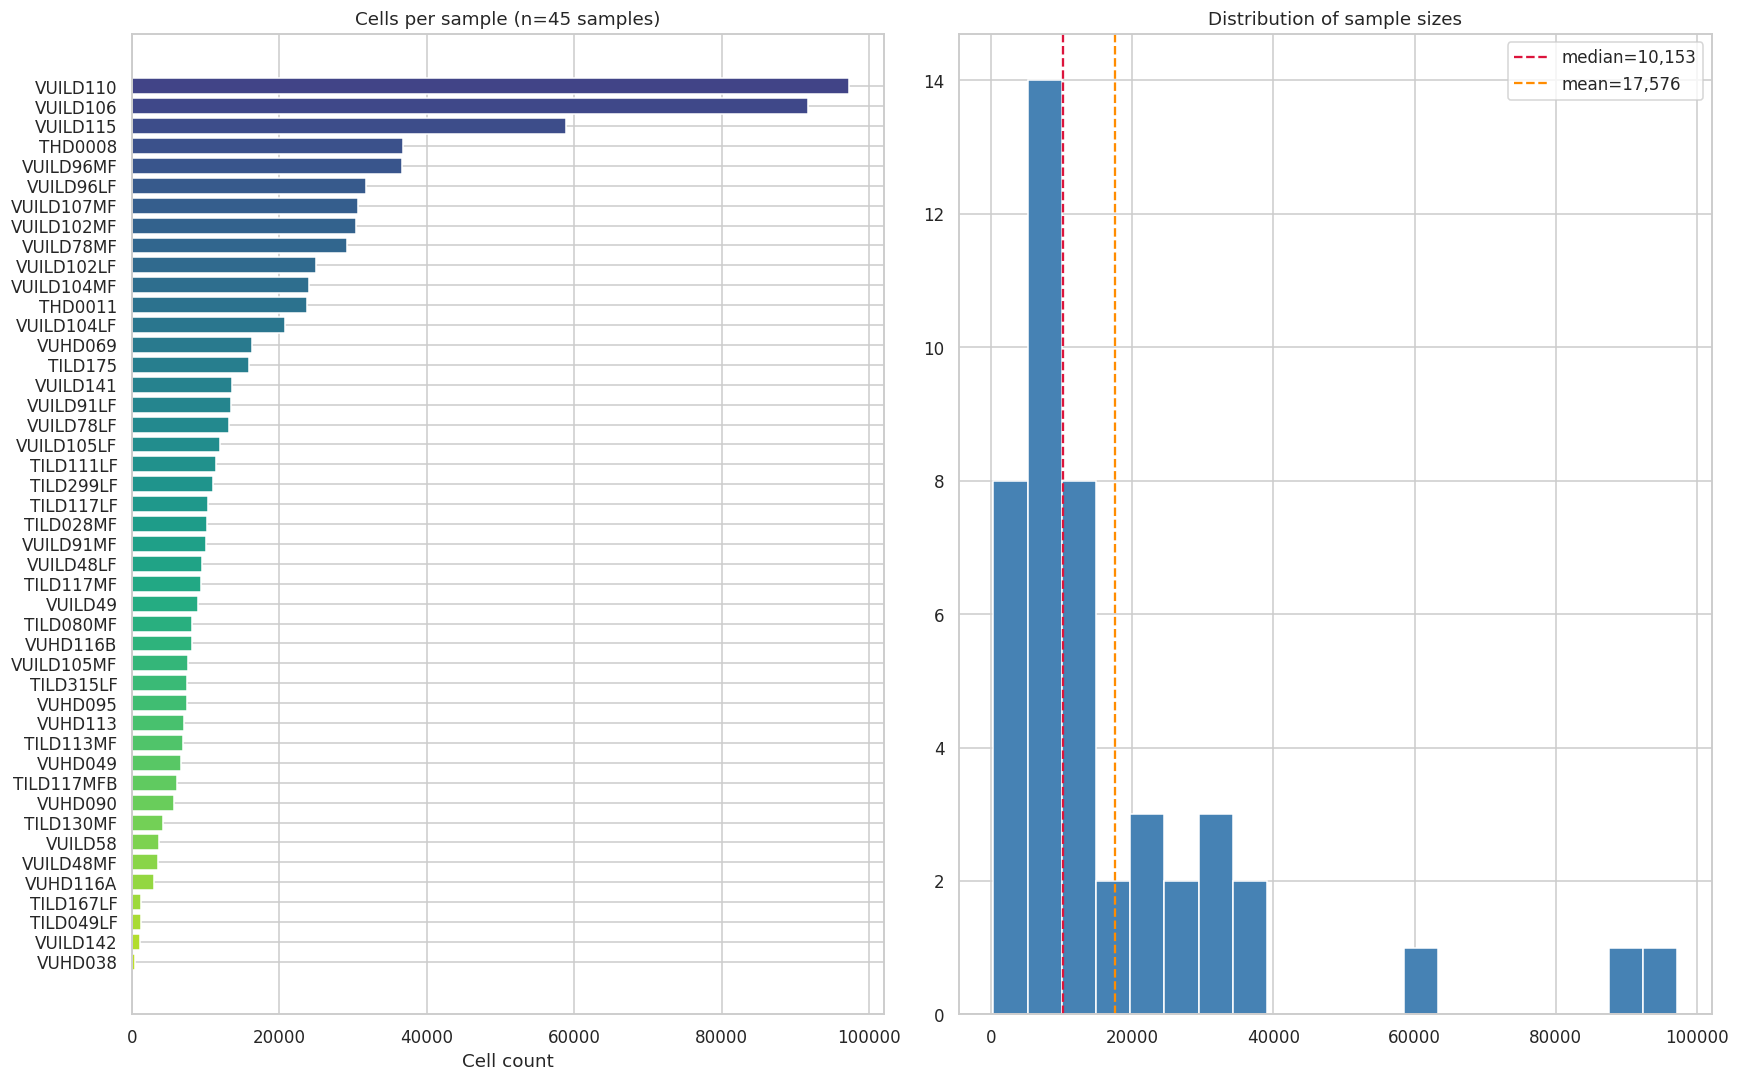

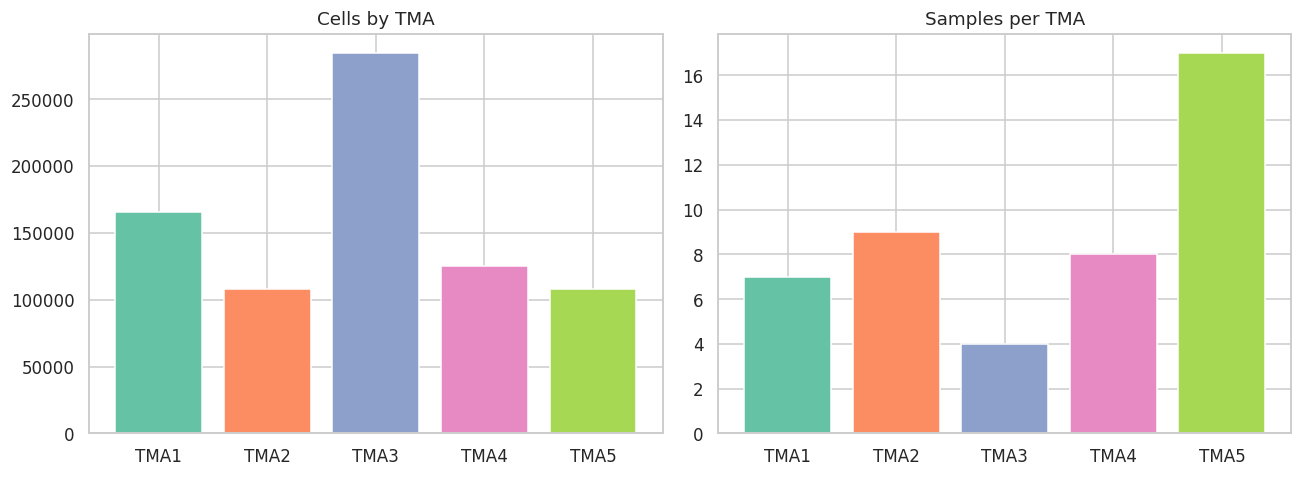

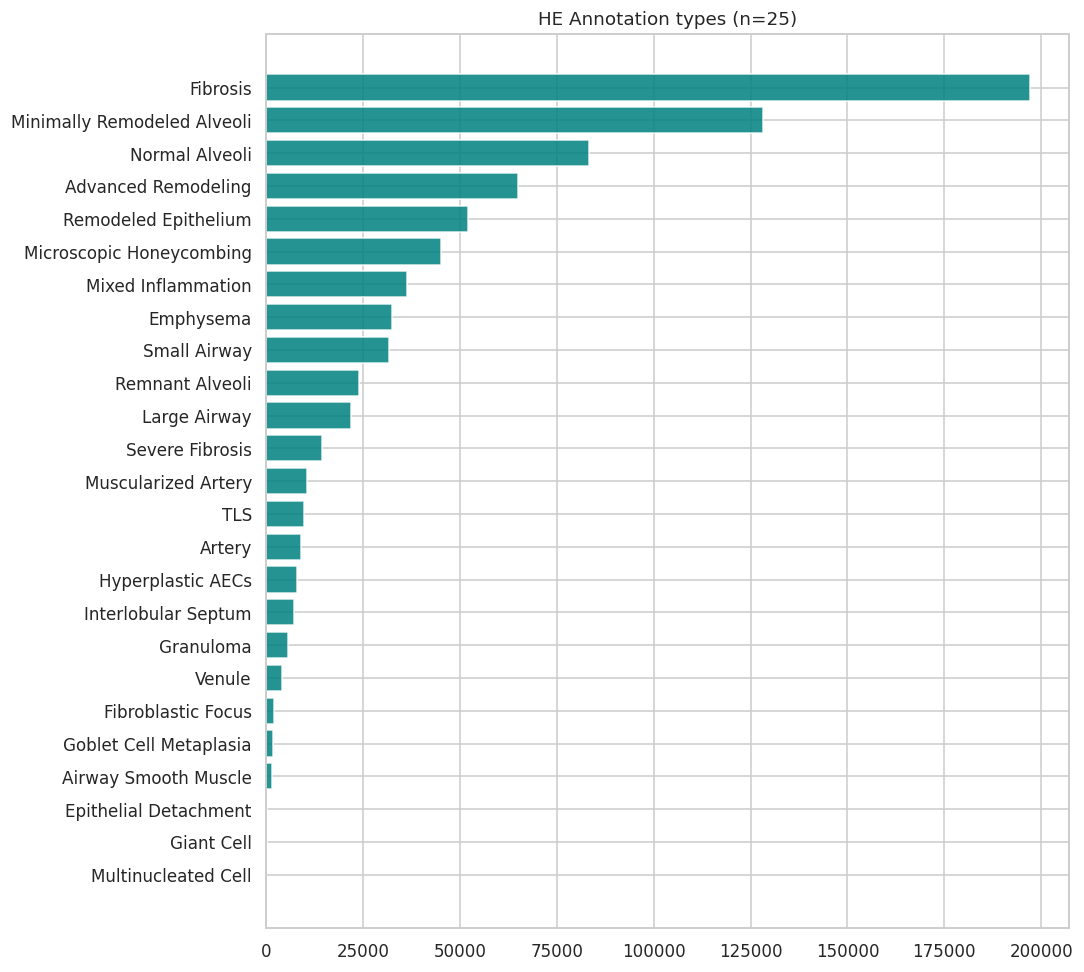

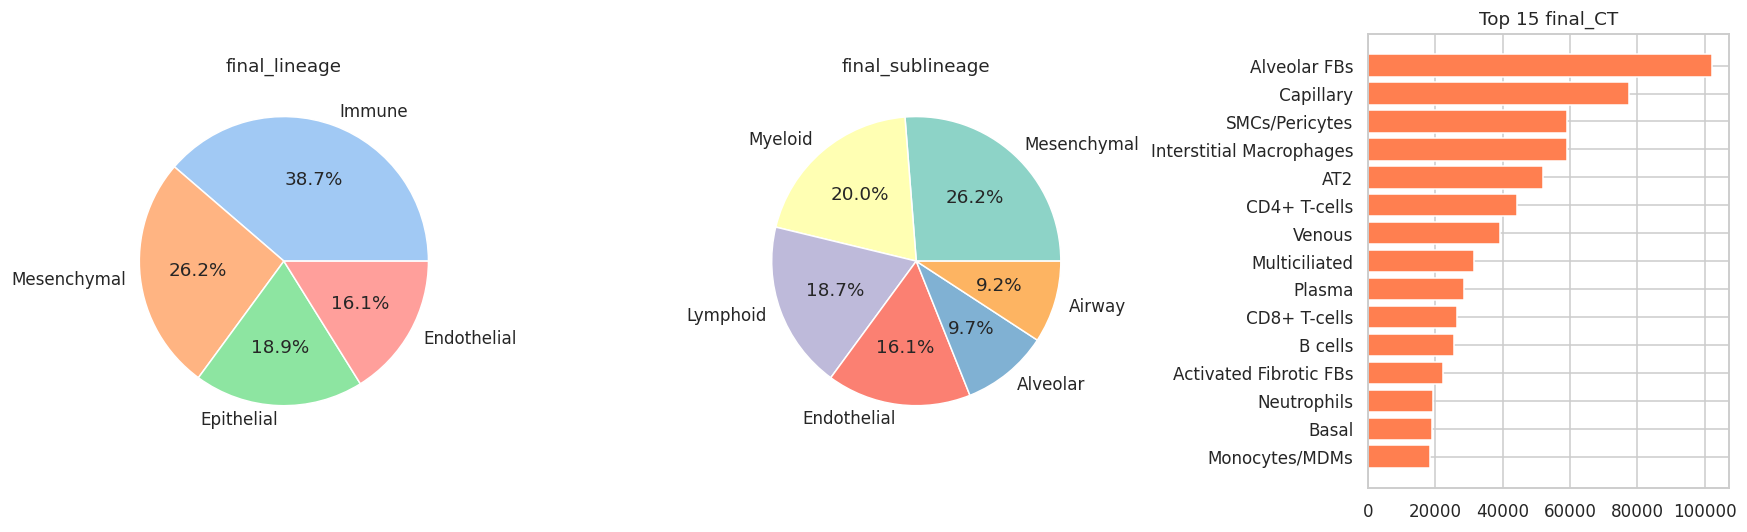

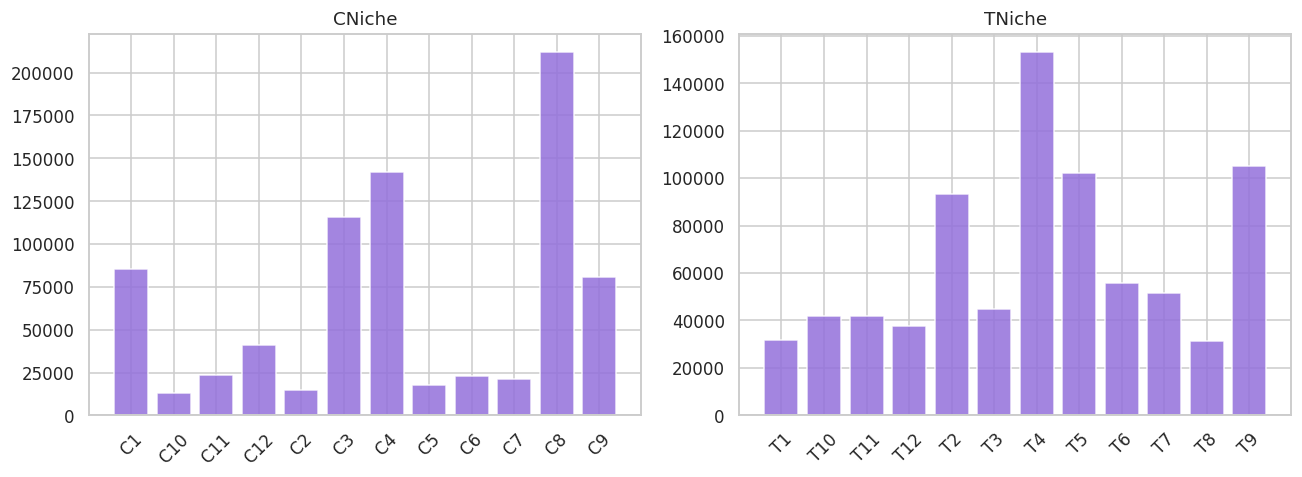

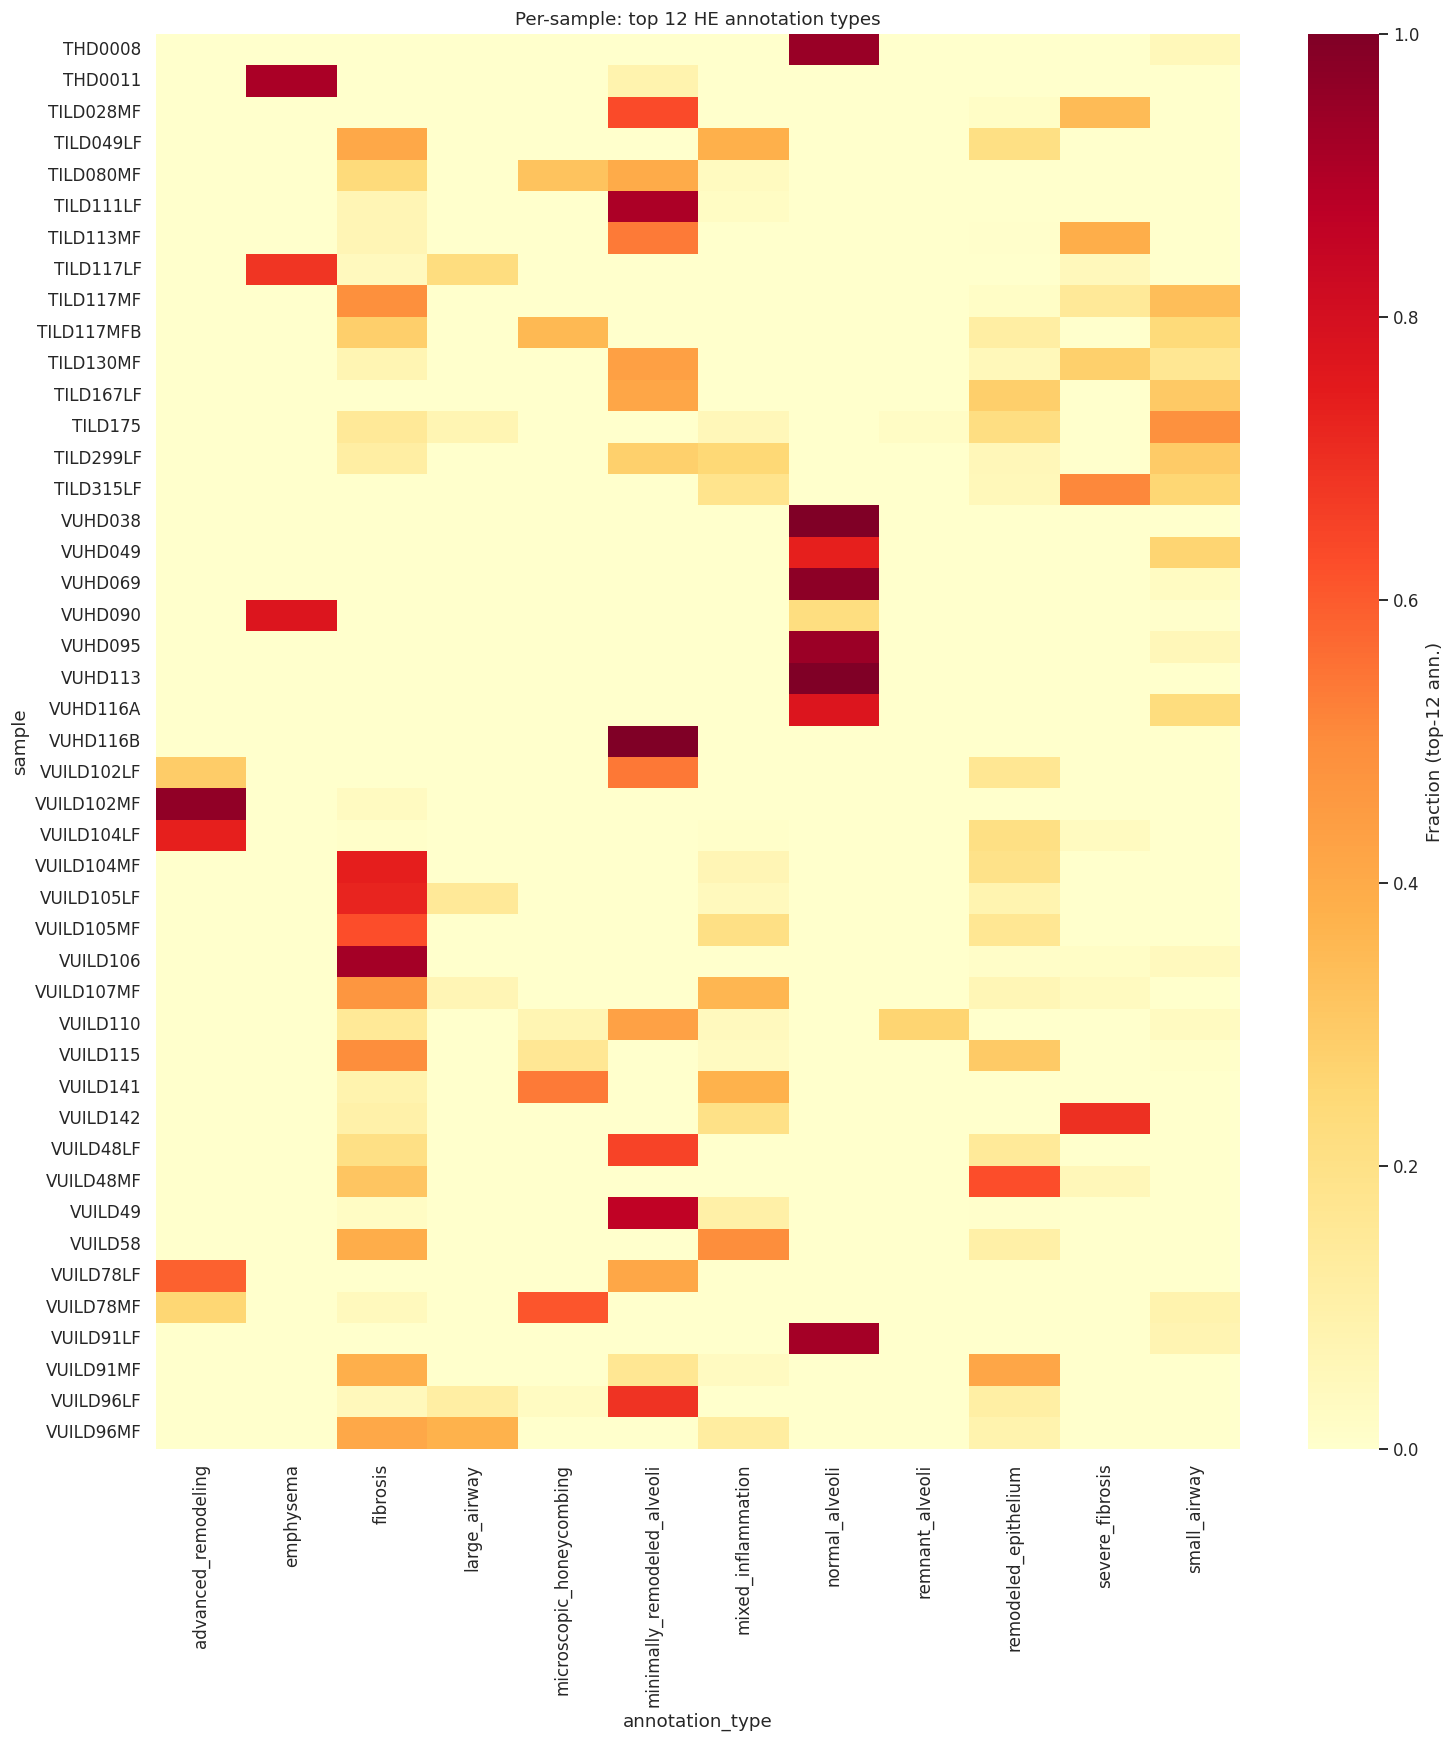

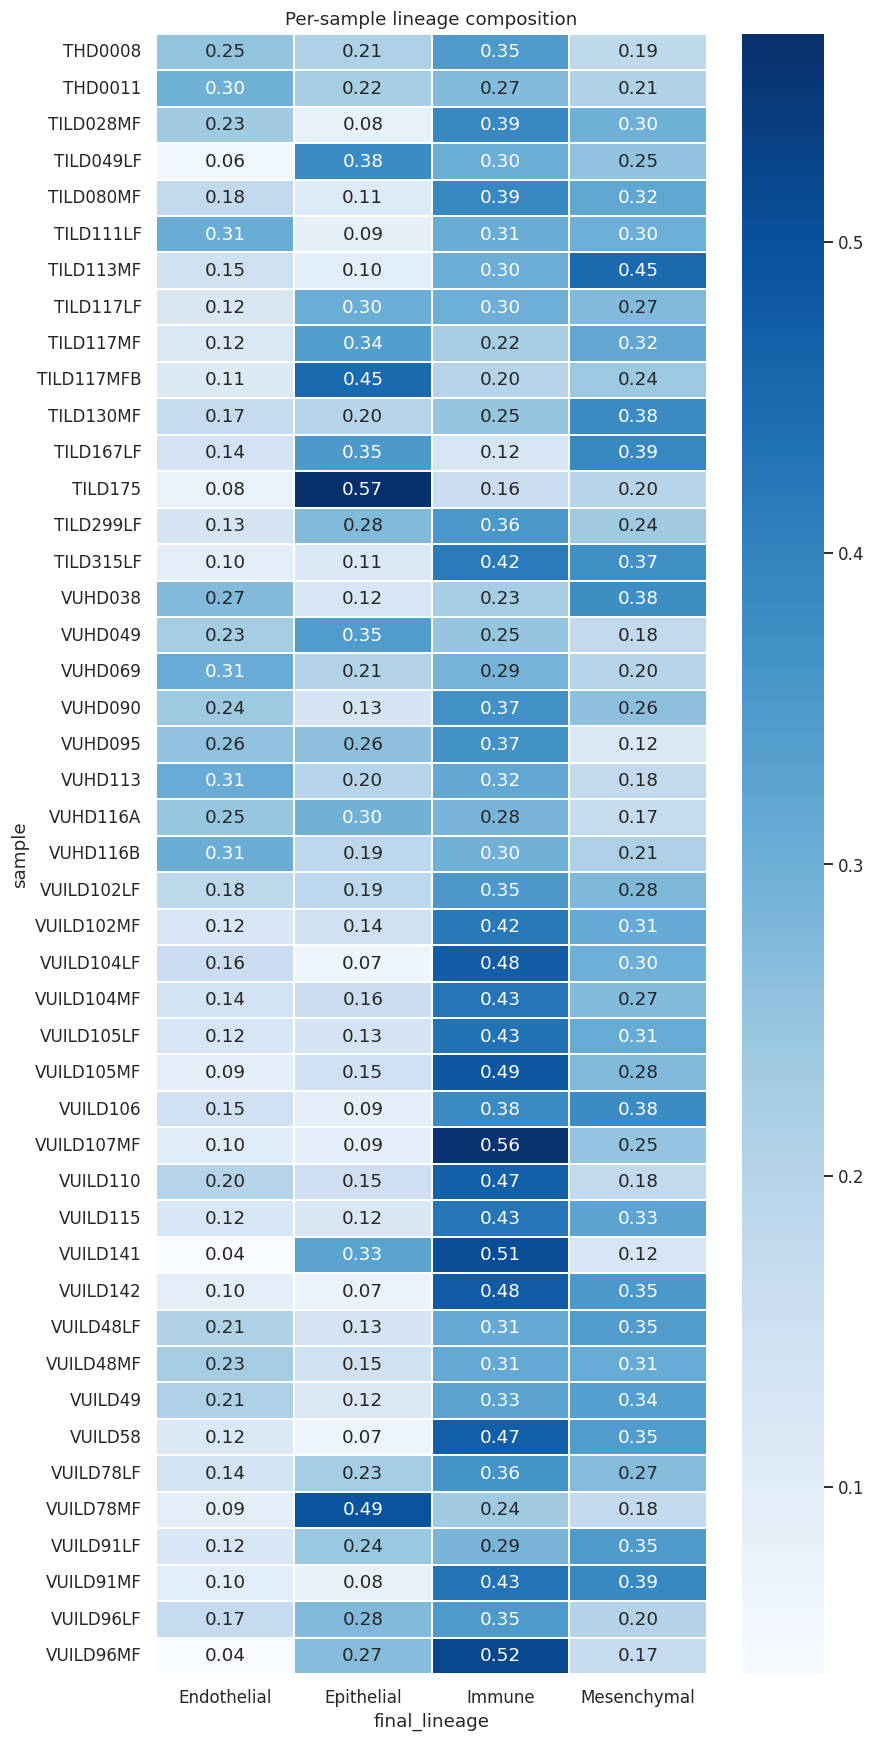

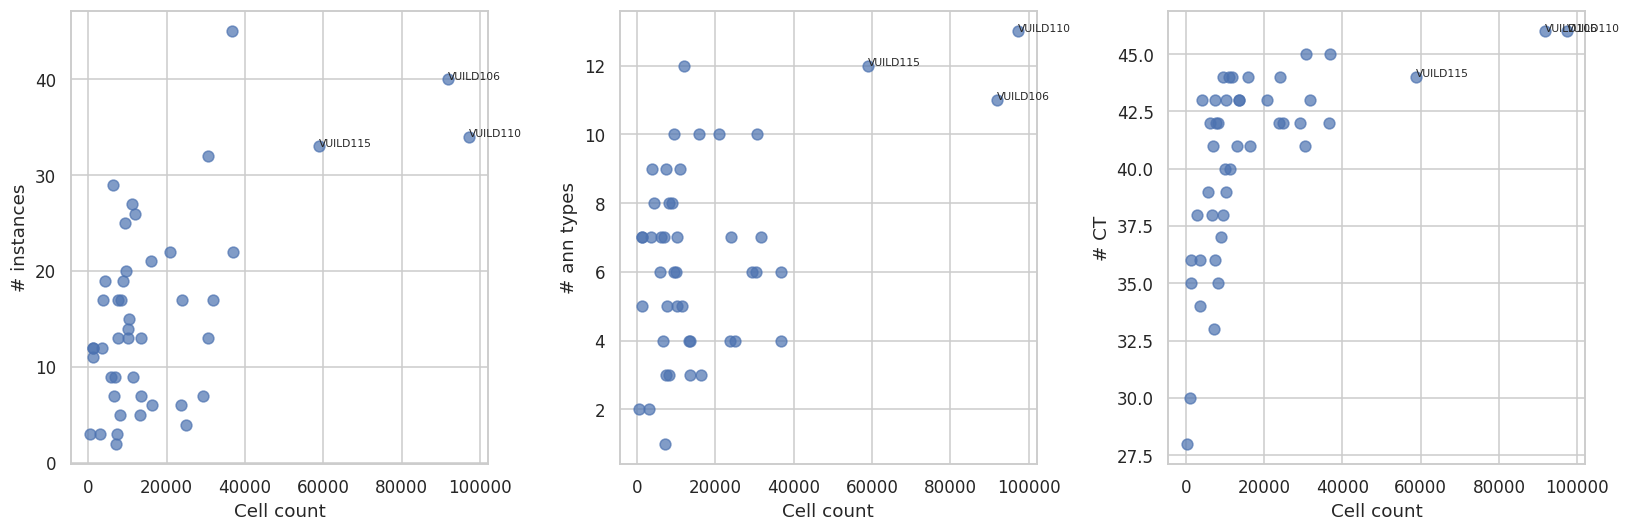

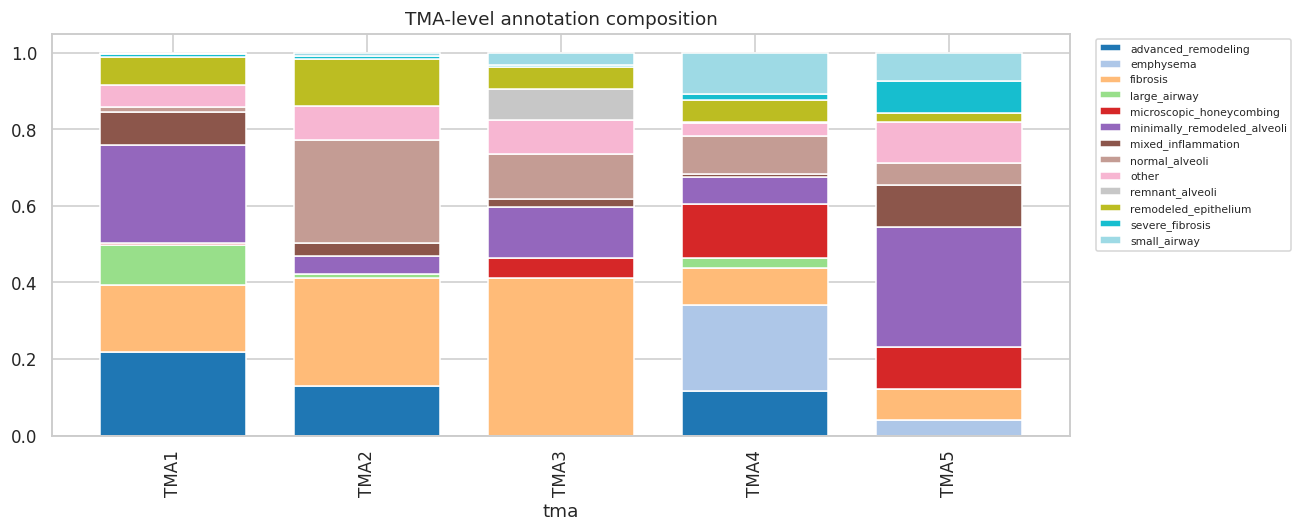

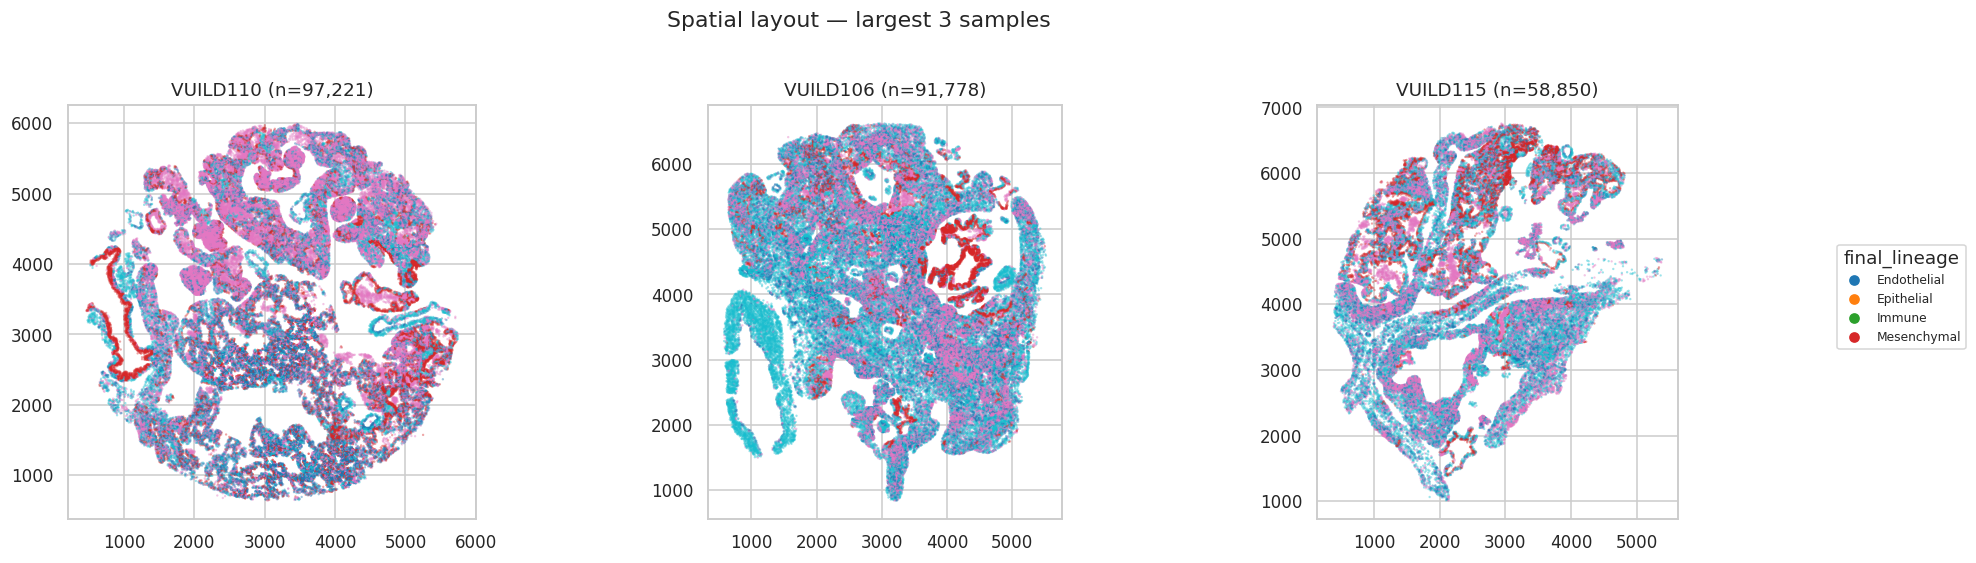

Saved to: /ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Annotation/HE_Annotations/Results/Figures


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# sns.set_theme(style='whitegrid', context='notebook')
# plt.rcParams['figure.dpi'] = 110

# OUT_DIR = Path(HE_anno_GT_dir).parent / 'Results/Figures'
# OUT_DIR.mkdir(parents=True, exist_ok=True)

df = HE_anno_GT_df

cells_per_sample = df.groupby('sample').size().sort_values(ascending=False)
sample_summary = df.groupby('sample').agg(
    n_cells=('cell_id', 'count'),
    n_ann_instances=('annotation_type_instance', 'nunique'),
    n_ann_types=('annotation_type', 'nunique'),
    n_cell_types=('final_CT', 'nunique'),
    tma=('tma', 'first'),
).sort_values('n_cells', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cells_per_sample)))
axes[0].barh(cells_per_sample.index, cells_per_sample.values, color=colors)
axes[0].set_xlabel('Cell count')
axes[0].set_title(f'Cells per sample (n={len(cells_per_sample)} samples)')
axes[0].invert_yaxis()
axes[1].hist(cells_per_sample, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(cells_per_sample.median(), color='crimson', ls='--', label=f'median={cells_per_sample.median():,.0f}')
axes[1].axvline(cells_per_sample.mean(), color='darkorange', ls='--', label=f'mean={cells_per_sample.mean():,.0f}')
axes[1].legend(); axes[1].set_title('Distribution of sample sizes')
plt.tight_layout(); plt.savefig(OUT_DIR / '01_cells_per_sample.pdf', bbox_inches='tight'); plt.show()

tma_counts = df['tma'].value_counts().sort_index()
tma_sample = df.groupby('tma')['sample'].nunique()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(tma_counts.index, tma_counts.values, color=sns.color_palette('Set2', len(tma_counts)))
axes[0].set_title('Cells by TMA'); axes[1].bar(tma_sample.index, tma_sample.values, color=sns.color_palette('Set2', len(tma_sample)))
axes[1].set_title('Samples per TMA')
plt.tight_layout(); plt.savefig(OUT_DIR / '02_tma_distribution.pdf', bbox_inches='tight'); plt.show()

ann_counts = df['Annotation_Type'].value_counts()
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(ann_counts.index[::-1], ann_counts.values[::-1], color='teal', alpha=0.85)
ax.set_title(f'HE Annotation types (n={len(ann_counts)})')
plt.tight_layout(); plt.savefig(OUT_DIR / '03_annotation_types.pdf', bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
lineage = df['final_lineage'].value_counts()
axes[0].pie(lineage, labels=lineage.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[0].set_title('final_lineage')
sublineage = df['final_sublineage'].value_counts()
axes[1].pie(sublineage, labels=sublineage.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
axes[1].set_title('final_sublineage')
ct_top = df['final_CT'].value_counts().head(15)
axes[2].barh(ct_top.index[::-1], ct_top.values[::-1], color='coral'); axes[2].set_title('Top 15 final_CT')
plt.tight_layout(); plt.savefig(OUT_DIR / '04_lineage_celltype.pdf', bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ['CNiche', 'TNiche']):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='mediumpurple', alpha=0.85)
    ax.set_title(col); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(OUT_DIR / '05_niches.pdf', bbox_inches='tight'); plt.show()

top_ann = df['annotation_type'].value_counts().head(12).index
prop = df[df['annotation_type'].isin(top_ann)].groupby(['sample', 'annotation_type']).size().unstack(fill_value=0)
prop_pct = prop.div(prop.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(prop_pct, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Fraction (top-12 ann.)'})
ax.set_title('Per-sample: top 12 HE annotation types')
plt.tight_layout(); plt.savefig(OUT_DIR / '06_sample_x_annotation_heatmap.pdf', bbox_inches='tight'); plt.show()

lin_pct = df.groupby(['sample', 'final_lineage']).size().unstack(fill_value=0)
lin_pct = lin_pct.div(lin_pct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8, 16))
sns.heatmap(lin_pct, cmap='Blues', ax=ax, annot=True, fmt='.2f', linewidths=0.3)
ax.set_title('Per-sample lineage composition')
plt.tight_layout(); plt.savefig(OUT_DIR / '07_sample_x_lineage_heatmap.pdf', bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, ylab in zip(axes, ['n_ann_instances', 'n_ann_types', 'n_cell_types'], ['# instances', '# ann types', '# CT']):
    ax.scatter(sample_summary['n_cells'], sample_summary[col], alpha=0.7, s=50)
    ax.set_xlabel('Cell count'); ax.set_ylabel(ylab)
    for s in sample_summary.nlargest(3, 'n_cells').index:
        ax.annotate(s, sample_summary.loc[s, ['n_cells', col]], fontsize=7)
plt.tight_layout(); plt.savefig(OUT_DIR / '08_sample_diversity.pdf', bbox_inches='tight'); plt.show()

tma_ann = pd.crosstab(df['tma'], df['annotation_type'].where(df['annotation_type'].isin(top_ann), other='other'))
fig, ax = plt.subplots(figsize=(12, 5))
tma_ann.div(tma_ann.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75)
ax.set_title('TMA-level annotation composition'); ax.legend(bbox_to_anchor=(1.02, 1), fontsize=7)
plt.tight_layout(); plt.savefig(OUT_DIR / '09_tma_annotation_stacked.pdf', bbox_inches='tight'); plt.show()

from matplotlib.lines import Line2D

lineages = sorted(df['final_lineage'].dropna().unique())
lineage_to_code = {lin: i for i, lin in enumerate(lineages)}
lineage_colors = plt.get_cmap('tab10')(np.arange(len(lineages)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, s in zip(axes, cells_per_sample.head(3).index):
    sub = df[df['sample'] == s]
    ax.scatter(
        sub['x_centroid'], sub['y_centroid'],
        c=sub['final_lineage'].map(lineage_to_code),
        s=0.3, alpha=0.4, cmap='tab10', vmin=0, vmax=len(lineages) - 1,
    )
    ax.set_title(f'{s} (n={len(sub):,})'); ax.set_aspect('equal')
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=6, color=c, label=lin)
    for lin, c in zip(lineages, lineage_colors)
]
fig.legend(handles=legend_handles, title='final_lineage', bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=8)
plt.suptitle('Spatial layout — largest 3 samples', y=1.02)
plt.tight_layout(); plt.savefig(OUT_DIR / '10_spatial_examples.png', bbox_inches='tight'); plt.show()    # two many dots

sample_summary.to_csv(OUT_DIR / 'sample_summary.csv')
ann_counts.to_frame('count').to_csv(OUT_DIR / 'annotation_type_counts.csv')
print(f'Saved to: {OUT_DIR.resolve()}')

## 2. Load sample & demographic information 
 - DavisXenium.csv by LLY
 - 41588_2025_2080_MOESM5_ESM.xlsx from Supplenmentary
   - Supplementary Table 1: Sample and demographic information. 
   - Supplementary Table 2: Cell counts per sample, per cell type, and total.
   - Supplementary Table 6: Pathology scoring per biopsy. Percent pathology represents the percent of the sample with pathology.

In [ ]:
## Wide sample-level table (metadata + cell-type counts per sample)

#####################
# created by LLY
#####################
# paper_supply_sample_sele_dir = f'{Xenium_lung_dir}Annotation/HE_Annotations/Results/DavisXenium_CreatedFromSupply.csv'
# paper_supply_sample_sele = pd.read_csv(paper_supply_sample_sele_dir)
# display(paper_supply_sample_sele)

#####################
# Paper's Supply
#####################
sheet_name='Supplementary Table 6'
paper_supply_sample_dir = f'{Xenium_lung_dir}Annotation/HE_Annotations/Results/41588_2025_2080_MOESM5_ESM.xlsx'

paper_supply_sample_all = pd.read_excel(paper_supply_sample_dir, sheet_name=sheet_name, header=1)
print('The shape of paper_all:', paper_supply_sample_all.shape)
display(paper_supply_sample_all)

The shape of paper_all: (45, 3)


,Sample,Percent pathology,Sample category
0,THD0008,0,Unaffected
1,THD0011,20,Unaffected
2,TILD028LA,45,Less Affected
3,TILD049MA,100,More Affected
4,TILD080LA,65,Less Affected
5,TILD111LA,20,Less Affected
6,TILD113LA,55,Less Affected
7,TILD117LA,50,Less Affected
8,TILD117MA1,95,More Affected
9,TILD117MA2,90,More Affected


In [ ]:
## 2026.06.20 Match the samples between paper_Supply and weiqin_Label

# SELECT_SAMPLES = ['VUHD113', 'VUILD107MA', 'VUILD102LA', 'VUILD96LA']        # select 4 samples
SELECT_SAMPLES = paper_supply_sample_all['Sample'].dropna().unique().tolist()  # select all samples

# Paper sample IDs (Supplementary Table 6) -> Weiqin cells_partitioned_by_annotation.csv sample IDs
PAPER_TO_WEIQIN = {
    'THD0008': 'THD0008', 'THD0011': 'THD0011',
    'VUHD038': 'VUHD038', 'VUHD049': 'VUHD049', 'VUHD069': 'VUHD069',
    'VUHD090': 'VUHD090', 'VUHD095': 'VUHD095', 'VUHD113': 'VUHD113',
    'VUHD116A': 'VUHD116A', 'VUHD116B': 'VUHD116B',
    ## 2026.06.22
    'TILD111LA': 'TILD111LF', 'TILD117LA': 'TILD117LF', 'TILD167LA': 'TILD167LF',
    'TILD117MA1': 'TILD117MF', 'TILD117MA2': 'TILD117MFB',
    'TILD028LA': 'TILD028MF', 'TILD049MA': 'TILD049LF', 'TILD080LA': 'TILD080MF',
    'TILD113LA': 'TILD113MF', 'TILD130LA': 'TILD130MF',
    'TILD299MA': 'TILD299LF', 'TILD315MA': 'TILD315LF',
    'TILD175MA': 'TILD175',
    'VUILD78LA': 'VUILD78LF', 'VUILD91LA': 'VUILD91LF', 'VUILD96LA': 'VUILD96LF',
    'VUILD102LA': 'VUILD102LF',
    'VUILD78MA': 'VUILD78MF', 'VUILD91MA': 'VUILD91MF', 'VUILD96MA': 'VUILD96MF',
    'VUILD102MA': 'VUILD102MF', 'VUILD107MA': 'VUILD107MF',
    'VUILD48LA1': 'VUILD48LF', 'VUILD48LA2': 'VUILD48MF',
    'VUILD104MA1': 'VUILD104LF', 'VUILD104MA2': 'VUILD104MF',   # Note
    'VUILD105MA1': 'VUILD105LF', 'VUILD105MA2': 'VUILD105MF',   # Note
    'VUILD49LA': 'VUILD49', 'VUILD58MA': 'VUILD58', 'VUILD106MA': 'VUILD106',
    'VUILD110LA': 'VUILD110', 'VUILD115MA': 'VUILD115',
    'VUILD141MA': 'VUILD141', 'VUILD142MA': 'VUILD142',
}
WEIQIN_TO_PAPER = {v: k for k, v in PAPER_TO_WEIQIN.items()}

HE_anno_GT_df_all = pd.read_csv(HE_anno_GT_dir)
weiqin_ids = sorted({PAPER_TO_WEIQIN[s] for s in SELECT_SAMPLES if s in PAPER_TO_WEIQIN})
unknown_paper = sorted(set(SELECT_SAMPLES) - set(PAPER_TO_WEIQIN))
if unknown_paper:
    print('WARNING: paper samples without mapping:', unknown_paper)

HE_anno_GT_df_all_sample_match = HE_anno_GT_df_all[HE_anno_GT_df_all['sample'].isin(weiqin_ids)].copy()
HE_anno_GT_df_all_sample_match['sample'] = HE_anno_GT_df_all_sample_match['sample'].replace(WEIQIN_TO_PAPER)

full_cell_id = HE_anno_GT_df_all_sample_match['full_cell_id']
for weiqin_id, paper_id in sorted(WEIQIN_TO_PAPER.items(), key=lambda kv: len(kv[0]), reverse=True):
    if weiqin_id != paper_id:
        full_cell_id = full_cell_id.str.replace(f'{weiqin_id}_', f'{paper_id}_', regex=False)
HE_anno_GT_df_all_sample_match['full_cell_id'] = full_cell_id


missing_weiqin = sorted(set(weiqin_ids) - set(HE_anno_GT_df_all['sample'].unique()))
if missing_weiqin:
    print('WARNING: no Weiqin rows for sample id:', missing_weiqin)

print('Per-cell rows by sample (after rename):')
print(HE_anno_GT_df_all_sample_match.groupby('sample').size().to_string())
print(f'Total: {len(HE_anno_GT_df_all_sample_match):,} rows × {HE_anno_GT_df_all_sample_match.shape[1]} cols')
display(HE_anno_GT_df_all_sample_match.head())

Per-cell rows by sample (after rename):
sample
THD0008        36781
THD0011        23676
TILD028LA      10153
TILD049MA       1210
TILD080LA       8194
TILD111LA      11379
TILD113LA       6867
TILD117LA      10288
TILD117MA1      9360
TILD117MA2      6166
TILD130LA       4181
TILD167LA       1213
TILD175MA      15866
TILD299MA      11055
TILD315MA       7472
VUHD038          345
VUHD049         6600
VUHD069        16343
VUHD090         5704
VUHD095         7401
VUHD113         7098
VUHD116A        2920
VUHD116B        8126
VUILD102LA     24925
VUILD102MA     30425
VUILD104MA1    20781
VUILD104MA2    23998
VUILD105MA1    11892
VUILD105MA2     7614
VUILD106MA     91778
VUILD107MA     30615
VUILD110LA     97221
VUILD115MA     58850
VUILD141MA     13526
VUILD142MA      1114
VUILD48LA1      9498
VUILD48LA2      3558
VUILD49LA       8918
VUILD58MA       3711
VUILD78LA      13125
VUILD78MA      29202
VUILD91LA      13463
VUILD91MA       9980
VUILD96LA      31727
VUILD96MA      36615
Total: 7

,sample,full_cell_id,cell_id,annotation_type_instance,annotation_type,annotation_instance,Annotation_Type,num_cells_annotation_type_instance,x_centroid,y_centroid,CNiche,TNiche,final_CT,final_lineage,final_sublineage,tma
0,VUHD116A,VUHD116A_aaaaaacg-1,aaaaaacg-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1663.692175,82.937963,C8,T4,SMCs/Pericytes,Mesenchymal,Mesenchymal,TMA1
1,VUHD116A,VUHD116A_aaaaaacl-1,aaaaaacl-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1669.976282,382.249965,C8,T4,Capillary,Endothelial,Endothelial,TMA1
2,VUHD116A,VUHD116A_aaaaaacp-1,aaaaaacp-1,normal_alveoli_3,normal_alveoli,2,Normal Alveoli,1512,2496.735547,757.727945,C8,T4,Alveolar FBs,Mesenchymal,Mesenchymal,TMA1
3,VUHD116A,VUHD116A_aaaaaadb-1,aaaaaadb-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1644.208582,73.882906,C8,T4,Capillary,Endothelial,Endothelial,TMA1
4,VUHD116A,VUHD116A_aaaaaadc-1,aaaaaadc-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1658.244061,379.432784,C8,T4,Capillary,Endothelial,Endothelial,TMA1


Text(0.5, 1.0, 'Distribution of sample sizes')

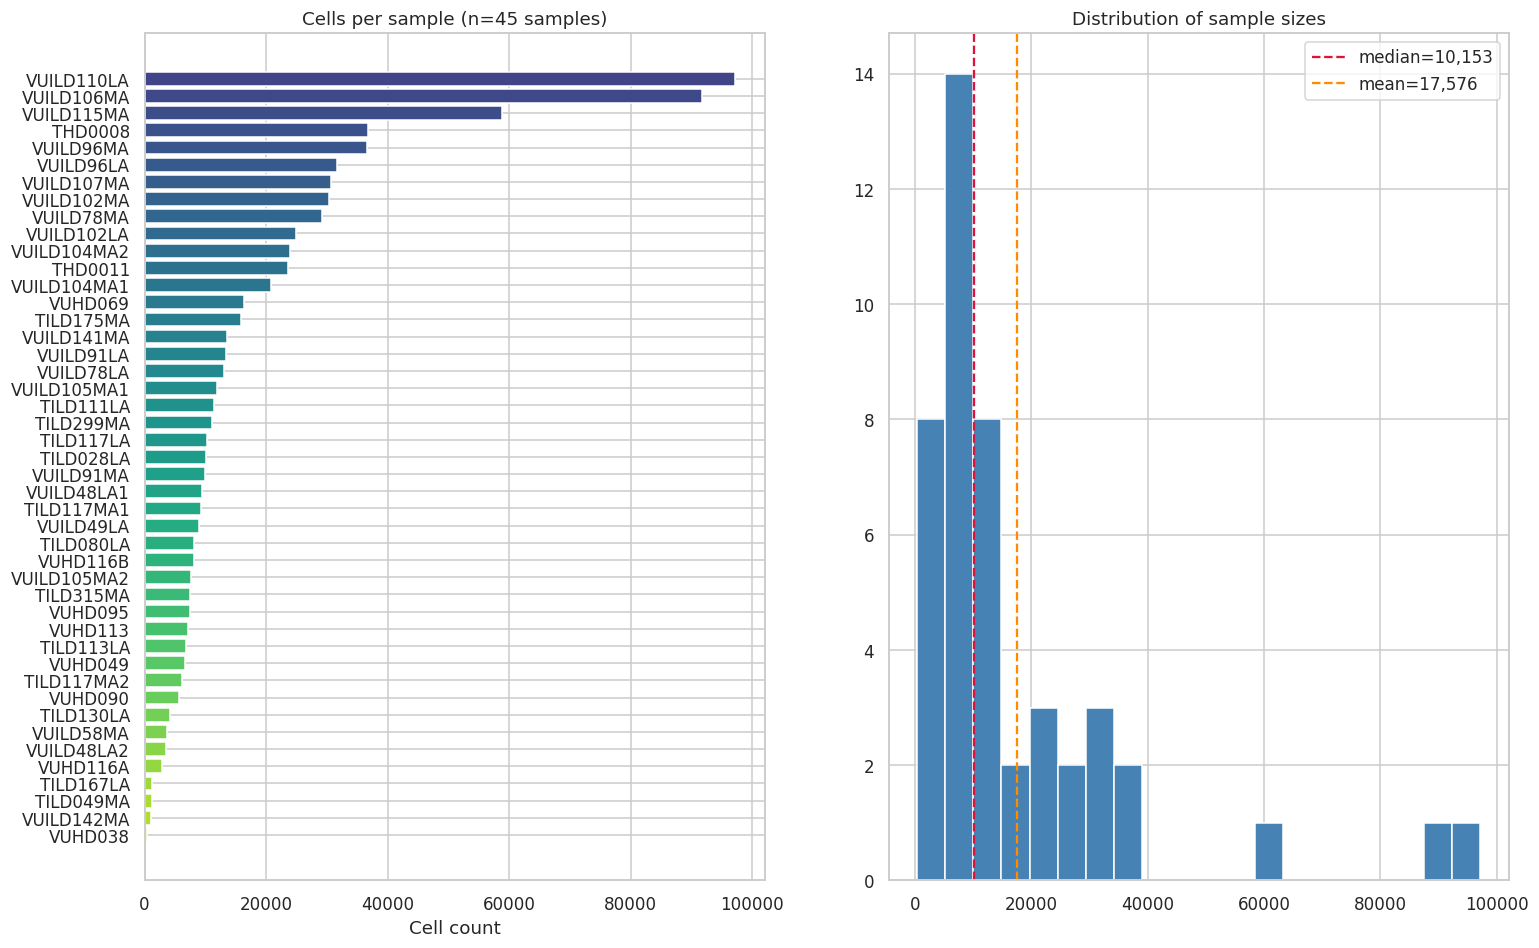

In [ ]:
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

OUT_DIR = Path(HE_anno_GT_dir).parent / 'Results/Figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

cells_per_sample = HE_anno_GT_df_all_sample_match.groupby('sample').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cells_per_sample)))
axes[0].barh(cells_per_sample.index, cells_per_sample.values, color=colors)
axes[0].set_xlabel('Cell count')
axes[0].set_title(f'Cells per sample (n={len(cells_per_sample)} samples)')
axes[0].invert_yaxis()
axes[1].hist(cells_per_sample, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(cells_per_sample.median(), color='crimson', ls='--', label=f'median={cells_per_sample.median():,.0f}')
axes[1].axvline(cells_per_sample.mean(), color='darkorange', ls='--', label=f'mean={cells_per_sample.mean():,.0f}')
axes[1].legend(); axes[1].set_title('Distribution of sample sizes')
# plt.tight_layout(); plt.savefig(OUT_DIR / '01_cells_per_sample_sample_match.pdf', bbox_inches='tight'); plt.show()

In [ ]:
## 2026.06.21 After match samples, transfer um to pixel
from xenium_coords import add_he_pixel_columns
HE_anno_GT_df_all_sample_match_with_pixel = add_he_pixel_columns(
    HE_anno_GT_df_all_sample_match,
    cases_roots=(COMPLETE_CASES, INCOMPLETE_CASES),
)
print('The shape of HE_anno_GT_df_all_sample_match:', HE_anno_GT_df_all_sample_match_with_pixel.shape)
display(HE_anno_GT_df_all_sample_match_with_pixel.head())

## save renamed cells_partitioned_by_annotation_sample_match_with_pixel.csv
HE_anno_GT_dir_sample_match_with_pixel = f'{Xenium_lung_dir}Annotation/HE_Annotations/cells_partitioned_by_annotation_sample_match_with_pixel.csv'
# HE_anno_GT_df_all_sample_match_with_pixel.to_csv(HE_anno_GT_dir_sample_match_with_pixel, index=False)

The shape of HE_anno_GT_df_all_sample_match: (790934, 18)


,sample,full_cell_id,cell_id,annotation_type_instance,annotation_type,annotation_instance,Annotation_Type,num_cells_annotation_type_instance,x_centroid,y_centroid,X_pix_HE,Y_pix_HE,CNiche,TNiche,final_CT,final_lineage,final_sublineage,tma
0,VUHD116A,VUHD116A_aaaaaacg-1,aaaaaacg-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1663.692175,82.937963,7829.139648,390.296295,C8,T4,SMCs/Pericytes,Mesenchymal,Mesenchymal,TMA1
1,VUHD116A,VUHD116A_aaaaaacl-1,aaaaaacl-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1669.976282,382.249965,7858.711914,1798.823364,C8,T4,Capillary,Endothelial,Endothelial,TMA1
2,VUHD116A,VUHD116A_aaaaaacp-1,aaaaaacp-1,normal_alveoli_3,normal_alveoli,2,Normal Alveoli,1512,2496.735547,757.727945,11749.343750,3565.778564,C8,T4,Alveolar FBs,Mesenchymal,Mesenchymal,TMA1
3,VUHD116A,VUHD116A_aaaaaadb-1,aaaaaadb-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1644.208582,73.882906,7737.452148,347.684265,C8,T4,Capillary,Endothelial,Endothelial,TMA1
4,VUHD116A,VUHD116A_aaaaaadc-1,aaaaaadc-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1658.244061,379.432784,7803.501465,1785.566040,C8,T4,Capillary,Endothelial,Endothelial,TMA1


In [ ]:
## 2026.06.21 Split HE_anno_GT_df_all_sample_match_with_pixel into single files according to sample, and save to their own folders in Complete_Cases or Incomplete_Cases

# written = write_per_sample_cells(
#     HE_anno_GT_df_all_sample_match_with_pixel,
#     cases_roots=(Path(COMPLETE_CASES), Path(INCOMPLETE_CASES)),
# )
# print(f"Wrote {len(written)} per-sample file(s)")

Writing per-sample CSVs for up to 25 case folder(s) ...
  THD0008: 36,781 cells -> Complete_Cases/THD0008/THD0008_cells_partitioned_by_annotation_sample_match_with_pixel.csv
  THD0011: 23,676 cells -> Complete_Cases/THD0011/THD0011_cells_partitioned_by_annotation_sample_match_with_pixel.csv
  TILD117LA: 10,288 cells -> Complete_Cases/TILD117LA/TILD117LA_cells_partitioned_by_annotation_sample_match_with_pixel.csv
  TILD117MA1: 9,360 cells -> Complete_Cases/TILD117MA1/TILD117MA1_cells_partitioned_by_annotation_sample_match_with_pixel.csv
  TILD175MA: 15,866 cells -> Complete_Cases/TILD175MA/TILD175MA_cells_partitioned_by_annotation_sample_match_with_pixel.csv
  VUHD069: 16,343 cells -> Complete_Cases/VUHD069/VUHD069_cells_partitioned_by_annotation_sample_match_with_pixel.csv
  VUHD095: 7,401 cells -> Complete_Cases/VUHD095/VUHD095_cells_partitioned_by_annotation_sample_match_with_pixel.csv
  VUHD113: 7,098 cells -> Complete_Cases/VUHD113/VUHD113_cells_partitioned_by_annotation_sample_mat

## Test samples: Load zarr data with spatial coords
**Select4 samples:** VUHD113, VUILD107MA, VUILD102LA, VUILD96LA

In [ ]:
# from glob import glob
# tif_path_list = glob(f"{path}Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/*/data.zarr")
# tif_path_list.sort()
# len(tif_path_list)

4

In [ ]:
# from tqdm import tqdm
# import spatialdata as sd
# import os
# import matplotlib.pyplot as plt

# for tif_path in tqdm(tif_path_list):
#     sdata = sd.read_zarr(tif_path)
#     output_path = os.path.splitext(tif_path)[0] + '_Xenium_lowres.jpg'
#     plt.figure(figsize=(10, 10))
#     plt.scatter(sdata.tables["table"].obsm["spatial"][:, 0], sdata.tables["table"].obsm["spatial"][:, 1], s=0.5)
#     plt.axis("equal")
#     plt.gca().invert_yaxis()
#     plt.savefig(output_path, dpi=300)
#     plt.close()

### Extract `cell_labels` & `nucleus_labels` per cell (Complete_Cases_Select4)

Xenium zarr stores multiscale label images (`labels/cell_labels`, `labels/nucleus_labels`). Integer pixel values are segmentation IDs. Table `spatial` coordinates use micron space; label rasters use pixel space (scale ≈ 4.706 from shapes transform).

Output: `{sample}_cell_nucleus_labels.csv` per sample + combined `cell_nucleus_labels_all.csv`.


In [ ]:
## 2026.06.20 Extract cell coords from zarr, and transform um to pixel
##            save cell_nucleus_labels_all.csv in Complete_Cases_Select4

# select_dir = Path(f'{Xenium_lung_dir}Data/Complete_Cases_Select4')    # select 4 samples
select_dir = Path(f'{Xenium_lung_dir}Data/Complete_Cases')    # complete cases

label_tables = []
for zarr_path in sorted(select_dir.glob('*/data.zarr')):
    sample = zarr_path.parent.name
    out_csv = labels_csv_path(zarr_path.parent)
    df_labels = extract_labels(zarr_path, method='centroid')
    df_labels.to_csv(out_csv, index=False)
    label_tables.append(df_labels)
    print(f'{sample}: {len(df_labels):,} cells -> {out_csv.name}')

df_labels_all = pd.concat(label_tables, ignore_index=True)
combined_path = select_dir / 'Cell_spatial_coords_um_pix_from_zarr_all.csv'
df_labels_all.to_csv(combined_path, index=False)    # save in Complete_Cases
print(f'Combined: {combined_path} ({len(df_labels_all):,} rows)')
df_labels_all.head()

THD0008: 73,785 cells -> THD0008_spatial_coords_um_pix_from_zarr.csv


THD0011: 34,998 cells -> THD0011_spatial_coords_um_pix_from_zarr.csv


TILD117LA: 40,810 cells -> TILD117LA_spatial_coords_um_pix_from_zarr.csv


TILD117MA1: 52,165 cells -> TILD117MA1_spatial_coords_um_pix_from_zarr.csv


TILD175MA: 38,293 cells -> TILD175MA_spatial_coords_um_pix_from_zarr.csv


...

VUILD91LA: 16,431 cells -> VUILD91LA_spatial_coords_um_pix_from_zarr.csv


VUILD91MA: 26,396 cells -> VUILD91MA_spatial_coords_um_pix_from_zarr.csv


VUILD96LA: 46,277 cells -> VUILD96LA_spatial_coords_um_pix_from_zarr.csv


VUILD96MA: 59,609 cells -> VUILD96MA_spatial_coords_um_pix_from_zarr.csv
Combined: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases/Cell_spatial_coords_um_pix_from_zarr_all.csv (1,179,081 rows)


,sample,cell_id,cell_label,nucleus_label,x_centroid,y_centroid,X_pix_HE,Y_pix_HE
0,THD0008,aaaaaaab-1,1,1,1660.504364,4203.301050,7814.138184,19780.240234
1,THD0008,aaaaaaac-1,2,2,1659.752936,3999.795776,7810.602051,18822.568359
2,THD0008,aaaaaaad-1,3,3,1648.391138,3998.641968,7757.134766,18817.138672
3,THD0008,aaaaaaae-1,4,4,1645.646069,4006.597437,7744.216797,18854.576172
4,THD0008,aaaaaaaf-1,5,5,1672.562598,4011.011792,7870.882812,18875.349609


In [ ]:
df_labels_all['sample'].value_counts()

sample
VUILD106MA     140997
VUILD110LA     133369
VUILD115MA     108131
THD0008         73785
VUILD107MA      72153
VUILD96MA       59609
TILD117MA1      52165
VUILD96LA       46277
VUILD78MA       45690
TILD117LA       40810
VUILD104MA1     38984
TILD175MA       38293
VUILD78LA       35179
THD0011         34998
VUILD102MA      34750
VUILD48LA2      32868
VUHD116B        31189
VUILD102LA      27973
VUILD91MA       26396
VUILD105MA2     24843
VUHD069         23758
VUILD91LA       16431
VUHD113         14940
VUHD116A        12915
VUHD095         12578
Name: count, dtype: int64

Compare `HE_Annotations` 与 `Complete_Cases_Select4` 
- 在 df_paper 里出现的每个 VUHD113 细胞，其坐标与 df_labels_all 中相同 cell_id 的坐标一致。
- df_labels_all 的 x_centroid / y_centroid 来自 zarr 的 obsm['spatial']，与 Weiqin 注释表一致。

In [ ]:
## check the consistance
# VUHD113: compare df_labels_all vs df_paper centroids (same cell_id)

def check_consistency(sample_name, labels_all_path, labels_HE_path): 
    df_labels_all = pd.read_csv(labels_all_path)
    df_paper = pd.read_csv(labels_HE_path)

    labels_vu = df_labels_all[df_labels_all['sample'] == sample_name][['cell_id', 'x_centroid', 'y_centroid']]
    paper_vu = df_paper[df_paper['sample'] == sample_name][['cell_id', 'x_centroid', 'y_centroid']]

    cmp = labels_vu.merge(paper_vu, on='cell_id', suffixes=('_labels', '_paper'), how='outer', indicator=True)
    print('Counts: All_labels', len(labels_vu), '| HE_annotations', len(paper_vu))
    print(cmp['_merge'].value_counts(), sep='\n')

    both = cmp[cmp['_merge'] == 'both']
    dx = both['x_centroid_labels'] - both['x_centroid_paper']
    dy = both['y_centroid_labels'] - both['y_centroid_paper']
    print(f'Matched {len(both):,} cells | max |dx|={dx.abs().max():.2e} max |dy|={dy.abs().max():.2e} | All equal: {np.allclose(dx, 0) and np.allclose(dy, 0)}')
    print(f"{'*' * 20} {sample_name} done {'*' * 20}")

## 3. Command
```Python
conda run -n SeededNTM python code/Xenium_lung/extract_cell_spatial_coords.py  # not necessary 
conda run -n SeededNTM python code/Xenium_lung/match_HEanno_with_sample_pix.py  #  Get cells_partitioned_by_annotation_sample_match_with_pixel
```
**Select4 samples:** VUHD113, VUILD107MA, VUILD102LA, VUILD96LA


In [ ]:
# labels_all_path = f'{Xenium_lung_dir}Data/Complete_Cases_Select4/Cell_spatial_coords_um_pix_from_zarr_all.csv'
labels_all_path = f'{Xenium_lung_dir}Data/Complete_Cases/Cell_spatial_coords_um_pix_from_zarr_all.csv'
HE_anno_GT_dir_sample_match_with_pixel = f'{Xenium_lung_dir}Annotation/HE_Annotations/cells_partitioned_by_annotation_sample_match_with_pixel.csv'


from pathlib import Path
Complete_Cases_dir = Path(f'{Xenium_lung_dir}Data/Complete_Cases/')
for p in sorted(Complete_Cases_dir.iterdir()):
    if p.is_dir():
        print(p.name)
        check_consistency(p.name, labels_all_path, HE_anno_GT_dir_sample_match_with_pixel)

THD0008
Counts: All_labels 73785 | HE_annotations 36781
_merge
left_only     37010
both          36781
right_only        0
Name: count, dtype: int64
Matched 36,781 cells | max |dx|=5.00e-12 max |dy|=5.00e-12 | All equal: True
******************** THD0008 done ********************
THD0011
Counts: All_labels 34998 | HE_annotations 23676
_merge
both          23676
left_only     15265
right_only        0
Name: count, dtype: int64
Matched 23,676 cells | max |dx|=5.00e-12 max |dy|=5.00e-12 | All equal: True
******************** THD0011 done ********************
TILD117LA
Counts: All_labels 40810 | HE_annotations 10288
_merge
left_only     30524
both          10288
right_only        0
Name: count, dtype: int64
Matched 10,288 cells | max |dx|=5.00e-12 max |dy|=5.00e-12 | All equal: True
******************** TILD117LA done ********************
TILD117MA1
Counts: All_labels 52165 | HE_annotations 9360
_merge
left_only     42813
both           9360
right_only        0
Name: count, dtype: int64
Ma

## 4. Plot HE_anno results

In [ ]:
# Select4: per-cell table from DavisXenium.csv (run convert_davis_xenium_csv.py after editing wide table)
HE_anno_GT_dir_sample_match_with_pixel = f'{Xenium_lung_dir}Annotation/HE_Annotations/cells_partitioned_by_annotation_sample_match_with_pixel.csv'
labels_HE_df = pd.read_csv(HE_anno_GT_dir_sample_match_with_pixel)
print('labels_HE_df samples:', sorted(labels_HE_df['sample'].unique()))
print(f'rows: {len(labels_HE_df):,}')
labels_HE_df.head()

labels_HE_df samples: ['THD0008', 'THD0011', 'TILD028LA', 'TILD049MA', 'TILD080LA', 'TILD111LA', 'TILD113LA', 'TILD117LA', 'TILD117MA1', 'TILD117MA2', 'TILD130LA', 'TILD167LA', 'TILD175MA', 'TILD299MA', 'TILD315MA', 'VUHD038', 'VUHD049', 'VUHD069', 'VUHD090', 'VUHD095', 'VUHD113', 'VUHD116A', 'VUHD116B', 'VUILD102LA', 'VUILD102MA', 'VUILD104MA1', 'VUILD104MA2', 'VUILD105MA1', 'VUILD105MA2', 'VUILD106MA', 'VUILD107MA', 'VUILD110LA', 'VUILD115MA', 'VUILD141MA', 'VUILD142MA', 'VUILD48LA1', 'VUILD48LA2', 'VUILD49LA', 'VUILD58MA', 'VUILD78LA', 'VUILD78MA', 'VUILD91LA', 'VUILD91MA', 'VUILD96LA', 'VUILD96MA']
rows: 790,934


,sample,full_cell_id,cell_id,annotation_type_instance,annotation_type,annotation_instance,Annotation_Type,num_cells_annotation_type_instance,x_centroid,y_centroid,X_pix_HE,Y_pix_HE,CNiche,TNiche,final_CT,final_lineage,final_sublineage,tma
0,VUHD116A,VUHD116A_aaaaaacg-1,aaaaaacg-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1663.692175,82.937963,7829.139648,390.296295,C8,T4,SMCs/Pericytes,Mesenchymal,Mesenchymal,TMA1
1,VUHD116A,VUHD116A_aaaaaacl-1,aaaaaacl-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1669.976282,382.249965,7858.711914,1798.823364,C8,T4,Capillary,Endothelial,Endothelial,TMA1
2,VUHD116A,VUHD116A_aaaaaacp-1,aaaaaacp-1,normal_alveoli_3,normal_alveoli,2,Normal Alveoli,1512,2496.735547,757.727945,11749.343750,3565.778564,C8,T4,Alveolar FBs,Mesenchymal,Mesenchymal,TMA1
3,VUHD116A,VUHD116A_aaaaaadb-1,aaaaaadb-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1644.208582,73.882906,7737.452148,347.684265,C8,T4,Capillary,Endothelial,Endothelial,TMA1
4,VUHD116A,VUHD116A_aaaaaadc-1,aaaaaadc-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1658.244061,379.432784,7803.501465,1785.566040,C8,T4,Capillary,Endothelial,Endothelial,TMA1



SELECT_SAMPLES = ['VUHD113', 'VUILD107MA', 'VUILD102LA', 'VUILD96LA']

In [ ]:
# # select_dir = Path(Xenium_lung_dir) / "Data/Complete_Cases_Select4"
# select_dir = Path(Xenium_lung_dir) / "Data/Complete_Cases"
# SELECT_SAMPLES = {p.name for p in select_dir.iterdir() if p.is_dir()}

# # 3x2: CNiche, TNiche | final_lineage, final_sublineage | final_CT, (empty)
# for dataset_select in sorted(SELECT_SAMPLES):
#     save_path = select_dir / dataset_select / f"{dataset_select}_GT_spatial_maps.jpg"
#     save_path.parent.mkdir(parents=True, exist_ok=True)
#     out = plot_spatial_he_maps(
#         dataset_select,
#         labels_he_df=labels_HE_df,
#         spatial_cols=DEFAULT_SPATIAL_COLS,
#         subplot_rows=3,
#         subplot_cols=2,
#         figsize=(14, 18),
#         dpi=300,
#         save_path=save_path,
#         show=True,
#     )
#     print(f"Saved: {out}\n")


In [ ]:
# # select_dir = Path(Xenium_lung_dir) / "Data/Complete_Cases_Select4"
# select_dir = Path(Xenium_lung_dir) / "Data/Incomplete_Cases"
# SELECT_SAMPLES = {p.name for p in select_dir.iterdir() if p.is_dir()}

# # 3x2: CNiche, TNiche | final_lineage, final_sublineage | final_CT, (empty)
# for dataset_select in sorted(SELECT_SAMPLES):
#     save_path = select_dir / dataset_select / f"{dataset_select}_GT_spatial_maps.jpg"
#     save_path.parent.mkdir(parents=True, exist_ok=True)
#     out = plot_spatial_he_maps(
#         dataset_select,
#         labels_he_df=labels_HE_df,
#         spatial_cols=DEFAULT_SPATIAL_COLS,
#         subplot_rows=3,
#         subplot_cols=2,
#         figsize=(14, 18),
#         dpi=300,
#         save_path=save_path,
#         show=True,
#     )
#     print(f"Saved: {out}\n")


## 5. Load StarDist results

```Python
cd /home/lingyu/ssd2/Python/Collaborate/esccAI
conda run -n SeededNTM python code/Xenium_lung/copy_stardist_to_cases.py

conda run -n SeededNTM python code/Xenium_lung/copy_stardist_to_cases.py --no-replace
conda run -n SeededNTM python code/Xenium_lung/copy_stardist_to_cases.py --sample THD0008
```

In [ ]:
# 1) Copy StarDist CSV into Complete_Cases / Incomplete_Cases (replace=True overwrites)
copied_paths = copy_stardist_csvs(replace=True)

def load_star_dist_data(dataset_select='VUHD113'):
    """Read StarDist CSV from Complete_Cases or Incomplete_Cases/{sample}/."""
    case_dir = resolve_case_dir(dataset_select)
    if case_dir is None:
        raise FileNotFoundError(
            f'{dataset_select} not found under Complete_Cases or Incomplete_Cases'
        )
    star_dist_path = case_dir / f'{dataset_select}{STARDIST_CSV_SUFFIX}'
    if not star_dist_path.is_file():
        raise FileNotFoundError(f'Missing StarDist CSV: {star_dist_path}')

    star_dist_df = pd.read_csv(star_dist_path)
    star_dist_df['sample'] = dataset_select
    print(f'[{dataset_select}] StarDist CSV: {star_dist_path}')
    print(f'[{dataset_select}] cell number of star_dist:', star_dist_df.shape)
    return star_dist_df

SELECT_SAMPLES = sorted(
    p.name for p in STARDIST_SOURCE.iterdir() if p.is_dir()
)
star_dist_all = {
    s: load_star_dist_data(dataset_select=s)
    for s in SELECT_SAMPLES
    if resolve_case_dir(s) is not None
}
star_dist_ = star_dist_all['VUHD113']

StarDist source: /home/lingyu/data/Python/Collaborate/esccAI/data/Xenium/lung/StarDist_Segment
Processing 45 sample folder(s), replace=True
  THD0008: overwrote -> Complete_Cases/THD0008/THD0008_Float_prob0.01_nms_0.3.csv (5,431,266 bytes)
  THD0011: overwrote -> Complete_Cases/THD0011/THD0011_Float_prob0.01_nms_0.3.csv (2,694,008 bytes)
  TILD028LA: overwrote -> Incomplete_Cases/TILD028LA/TILD028LA_Float_prob0.01_nms_0.3.csv (4,021,289 bytes)
  TILD049MA: overwrote -> Incomplete_Cases/TILD049MA/TILD049MA_Float_prob0.01_nms_0.3.csv (2,975,826 bytes)
  TILD080LA: overwrote -> Incomplete_Cases/TILD080LA/TILD080LA_Float_prob0.01_nms_0.3.csv (9,067,492 bytes)
  TILD111LA: overwrote -> Incomplete_Cases/TILD111LA/TILD111LA_Float_prob0.01_nms_0.3.csv (5,426,721 bytes)
  TILD113LA: overwrote -> Incomplete_Cases/TILD113LA/TILD113LA_Float_prob0.01_nms_0.3.csv (8,555,919 bytes)
  TILD117LA: overwrote -> Complete_Cases/TILD117LA/TILD117LA_Float_prob0.01_nms_0.3.csv (3,602,767 bytes)
  TILD117MA1: 

In [ ]:
star_dist_ = load_star_dist_data(dataset_select='VUHD113')
star_dist_.head()

[VUHD113] StarDist CSV: /ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases/VUHD113/VUHD113_Float_prob0.01_nms_0.3.csv
[VUHD113] cell number of star_dist: (23745, 4)


,centroid_x,centroid_y,probability,sample
0,3678.293251,3560.173920,0.886976,VUHD113
1,3371.622482,3423.181580,0.883140,VUHD113
2,412.258600,795.808817,0.878218,VUHD113
3,3705.858780,3700.159309,0.874990,VUHD113
4,352.317239,705.626997,0.867907,VUHD113


### HE - StarDist

In [ ]:
## Load stardist coords (Complete_Cases_Select4/{sample}/)
therapy_data = 'VUHD113'
star_coords_path = f'{Xenium_lung_dir}Data/Complete_Cases/{therapy_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
star_coords = pd.read_csv(star_coords_path)
print(star_coords_path)
print(star_coords.shape)
star_coords.head()

/home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases/VUHD113/VUHD113_Float_prob0.01_nms_0.3.csv
(23745, 3)


,centroid_x,centroid_y,probability
0,3678.293251,3560.173920,0.886976
1,3371.622482,3423.181580,0.883140
2,412.258600,795.808817,0.878218
3,3705.858780,3700.159309,0.874990
4,352.317239,705.626997,0.867907


### Compare GT and StarDist

In [2]:
import sys
import os
import pandas as pd
import importlib
import pathlib

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Collaborate/esccAI/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords, load_hist_embeddings,
    match_hist2cell_matrix,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    split_train_test,
    prepare_data_leave_one_group_out,
    spatial_tile_groups_for_logo,
    loader_train_test,
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_WSI_counts_cor,
    plot_celltype_spatial_distribution,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_per_class_f1,
    plot_sunburst,
    plot_cell_area_histogram_zoom,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions,
    gt_stardist_counts_for_correlation,
    plot_gt_stardist_cell_counts_bar,
    plot_gt_stardist_spatial_mapping,
    plot_gt_stardist_counts_correlation,
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split,
    train_hce_leave_one_group_out_cv,
    run_logo_cv_and_load_best_model,
    report_logo_cv_means_and_insample_eval,
    run_logo_cv_with_insample_report,
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")

Successfully reloaded functions
openslide: False, tifffile: True


### Segment correlation

In [ ]:
# ## All level012
# therapy_data = 'NCRT'
# transfer_data = 'he_cell_coords'
# parent_value='tumor1'
# stardist_coords_path = f'{path}Collaborate/esccAI/data/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
# qupath_corner_path = f'{path}Collaborate/esccAI/data/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
# codex_meta_celltype_path = f'{path}Collaborate/esccAI/data/codex_meta_celltype_final012.csv'
# celltype_pixel_NCRT_path = f'{path}Collaborate/esccAI/data/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
# save_path = f'{path}Collaborate/esccAI/data/{transfer_data}/{therapy_data}_CellPixCoords_{parent_value}_StarDist.csv'
# save_path4ViT = f'{path}Collaborate/esccAI/data/{transfer_data}/{therapy_data}_CellPixCoords_{parent_value}_StarDist_ViT.csv'

In [ ]:
# celltype_anno_df, roi_cell_counts, star_coords_in_roi, celltype_pixel_NCRT = make_PCF2HE2StarDist_alignment(
#     stardist_coords_path,
#     qupath_corner_path,
#     codex_meta_celltype_path,
#     celltype_pixel_NCRT_path,
#     therapy_data=f'{therapy_data}',
#     parent_value='all',
#     save_path=save_path,
#     save_path4ViT=save_path4ViT
#     # save_path=None,
#     # save_path4ViT=None
# )

In [3]:
from pathlib import Path

data_class = 'Complete_Cases'
dataset_name = 'VUHD113'  # change for spatial mapping

# data_class = 'Incomplete_Cases'
# dataset_name = 'TILD028LA' 
cases_root = Path(Xenium_lung_dir) / 'Data' / data_class


GT_SUFFIX = '_cells_partitioned_by_annotation_sample_match_with_pixel.csv'
STARDIST_SUFFIX = '_Float_prob0.01_nms_0.3.csv'


def gt_csv_path(sample: str) -> Path:
    return cases_root / sample / f'{sample}{GT_SUFFIX}'


def stardist_csv_path(sample: str) -> Path:
    return cases_root / sample / f'{sample}{STARDIST_SUFFIX}'


def load_gt_coords(sample: str) -> pd.DataFrame:
    df = pd.read_csv(gt_csv_path(sample))
    df = df.dropna(subset=['X_pix_HE', 'Y_pix_HE']).copy()
    df['TumorID'] = f'{sample}_all'
    return df


def load_stardist_coords(sample: str) -> pd.DataFrame:
    df = pd.read_csv(stardist_csv_path(sample))
    df = df.dropna(subset=['centroid_x', 'centroid_y']).copy()
    df['TumorID'] = f'{sample}_all'
    return df

In [4]:
# 1) Count cells per sample (GT vs StarDist)
count_rows = []
for sample_dir in sorted(cases_root.iterdir()):
    if not sample_dir.is_dir():
        continue
    sample = sample_dir.name
    gt_path = gt_csv_path(sample)
    sd_path = stardist_csv_path(sample)
    if not gt_path.is_file() or not sd_path.is_file():
        print(f'SKIP {sample}: missing GT or StarDist CSV')
        continue
    n_gt = len(pd.read_csv(gt_path))
    n_sd = len(pd.read_csv(sd_path))
    count_rows.append({'sample': sample, 'n_gt': n_gt, 'n_stardist': n_sd})

counts_df = pd.DataFrame(count_rows).sort_values('sample').reset_index(drop=True)
counts_df['ratio_stardist_gt'] = counts_df['n_stardist'] / counts_df['n_gt']
print(counts_df.to_string(index=False))
print(f'\nSamples with both CSVs: {len(counts_df)}')

     sample  n_gt  n_stardist  ratio_stardist_gt
    THD0008 36781      113390           3.082842
    THD0011 23676       56679           2.393943
  TILD117LA 10288       75610           7.349339
 TILD117MA1  9360      123637          13.209081
  TILD175MA 15866       72751           4.585340
    VUHD069 16343       37354           2.285627
    VUHD095  7401       18343           2.478449
    VUHD113  7098       23745           3.345309
   VUHD116A  2920       18062           6.185616
   VUHD116B  8126       44690           5.499631
 VUILD102LA 24925       60484           2.426640
 VUILD102MA 30425      122380           4.022350
VUILD104MA1 20781       49586           2.386122
VUILD105MA2  7614       67638           8.883373
 VUILD106MA 91778      323241           3.521988
 VUILD107MA 30615      105857           3.457684
 VUILD110LA 97221      235636           2.423715
 VUILD115MA 58850      285742           4.855429
 VUILD48LA2  3558       40659          11.427487
  VUILD78LA 13125   

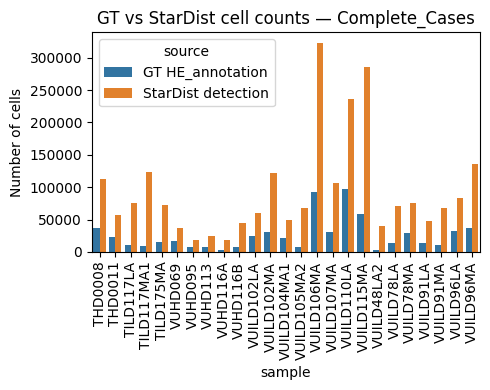

In [8]:
cell_counts_df = plot_gt_stardist_cell_counts_bar(
    counts_df,
    figure_size=(5, 4),
    title=f'GT vs StarDist cell counts — {data_class}',
    save_path=None
    # save_path=f'{Xenium_lung_dir}Data/{data_class}/Cell_spatial_counts_GT_vs_StarDist.pdf',
)

# display(cell_counts_df)
## save merged_all
# cell_counts_df.to_csv(f'{Xenium_lung_dir}Data/{data_class}/Cell_spatial_counts_GT_vs_StarDist.csv', index=False)

VUHD113_all - star_coords_in_roi shape: (23745, 4)
VUHD113_all - celltype_pixel_NCRT shape: (7098, 19)


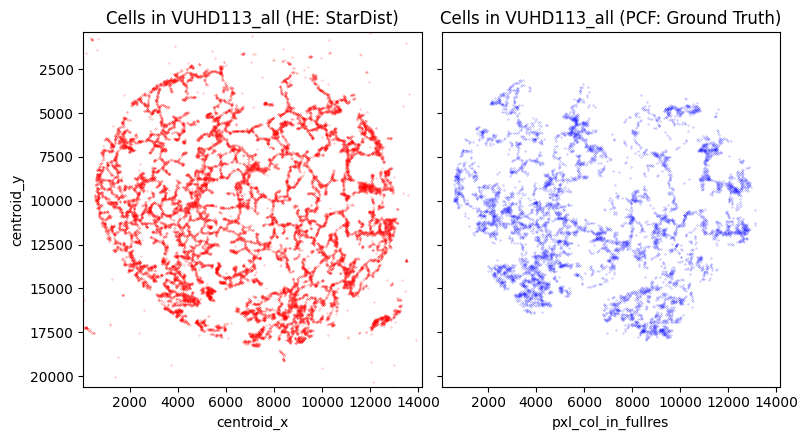

,TumorID,n_star_cells,n_pixel_cells
0,VUHD113_all,23745,7098


In [ ]:
# 2) Spatial mapping for one sample
gt_coords_df = load_gt_coords(dataset_name)
stardist_coords_df = load_stardist_coords(dataset_name)

merged_sample = plot_gt_stardist_spatial_mapping(
    stardist_coords_df,
    gt_coords_df,
    dataset_name,
    figure_size=(8, 4.5),
    save_path=None,
    # save_path=f'{Xenium_lung_dir}Data/{data_class}/Cell_spatial_counts_GT_vs_StarDist_{dataset_name}.pdf',
)
display(merged_sample)

TILD117MA1_all - star_coords_in_roi shape: (123637, 4)
TILD117MA1_all - celltype_pixel_NCRT shape: (9360, 19)


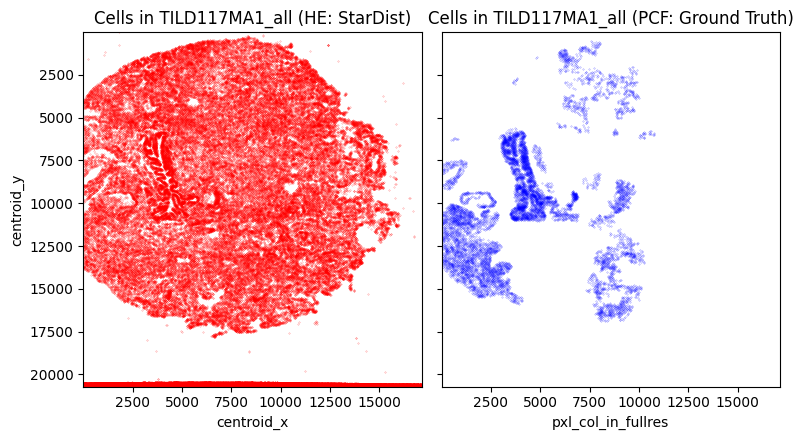

,TumorID,n_star_cells,n_pixel_cells
0,TILD117MA1_all,123637,9360


In [ ]:
# Optional: another sample
dataset_name = 'TILD117MA1'    # Complete: TILD117MA1
# dataset_name = 'VUILD48LA1'    # Incomplete: VUHD038    VUILD48LA1
merged_sample = plot_gt_stardist_spatial_mapping(
    load_stardist_coords(dataset_name),
    load_gt_coords(dataset_name),
    dataset_name,
    figure_size=(8, 4.5),
    save_path=None,
    # save_path=f'{Xenium_lung_dir}Data/{data_class}/Cell_spatial_counts_GT_vs_StarDist_{dataset_name}.pdf',
)
display(merged_sample)

In [ ]:
plot_gt_stardist_counts_correlation(
    counts_df,
    fig_size=(10, 5),
    dataset='Xenium_lung', 
    save_path=None,
    # save_path=f'{Xenium_lung_dir}Data/{data_class}/Cell_spatial_counts_correlation_GT_vs_StarDist.pdf',
)